# Effects of isoproterenol

In [1]:
using ModelingToolkit
using OrdinaryDiffEq, SteadyStateDiffEq, DiffEqCallbacks
using Plots
using CSV
using DataFrames
using Dates
using CaMKIIModel
using CaMKIIModel: second, μM
Plots.default(lw=1.5)

## Setup model

In [2]:
sys = build_neonatal_ecc_sys(simplify=true, reduce_iso=true, reduce_camk=true)
tend = 205second
prob = ODEProblem(sys, [], tend)
stimstart = 30second
stimend = 120second
alg = KenCarp47()

KenCarp47(; linsolve = nothing, nlsolve = OrdinaryDiffEqNonlinearSolve.NLNewton{Rational{Int64}, Rational{Int64}, Rational{Int64}, Rational{Int64}}(1//100, 10, 1//5, 1//5, false, true, 0//1), precs = DEFAULT_PRECS, smooth_est = true, extrapolant = linear, controller = PI, autodiff = ADTypes.AutoForwardDiff(),)

## Without isoproterenol

In [3]:
@unpack Istim = sys
callback = build_stim_callbacks(Istim, stimend; period=1second, starttime=stimstart)
@time sol = solve(prob, alg; callback)

 10.510353 seconds (28.92 M allocations: 1.312 GiB, 3.71% gc time, 88.01% compilation time)


retcode: Success
Interpolation: 3rd order Hermite
t: 4071-element Vector{Float64}:
      0.0
      0.019333123284849308
      0.09098129546757994
      0.20735582943983855
      0.45611910276862533
      1.0472562928406122
      2.0342667657223696
      3.451776641148454
      6.733792423912806
     12.450117081023194
      ⋮
 153525.25012366346
 158165.8598019807
 163776.6411118618
 169611.6642461836
 176342.19489586214
 183684.1140466068
 191258.90946281631
 199427.37350661293
 205000.0
u: 4071-element Vector{Vector{Float64}}:
 [0.0026, 830.0, 830.0, 0.00702, 0.966, 0.22156, 0.09243, 0.00188, 0.00977, 0.26081  …  0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, -68.79268, 13838.37602, 150952.75035000002]
 [0.0025985659590295374, 829.9994975880693, 829.9999654017583, 0.007020208561323646, 0.9660018276402699, 0.2215639938807744, 0.09242766669618695, 0.001879826176081169, 0.009769882842069916, 0.2608055799112056  …  0.12113000000000405, 0.12113000000038378, 0.1211300000138

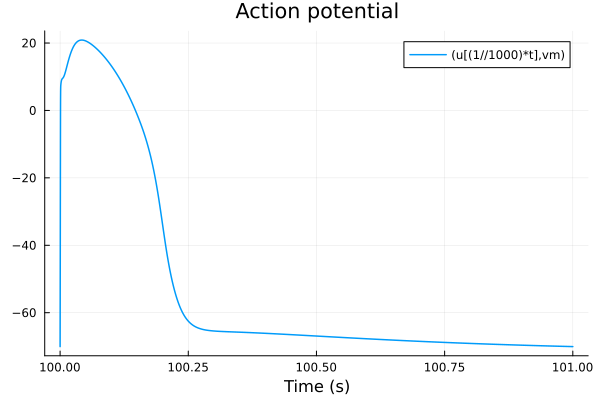

In [4]:
i = (sys.t / 1000, sys.vm)
plot(sol, idxs=i, tspan=(100second, 101second), title="Action potential", xlabel="Time (s)")

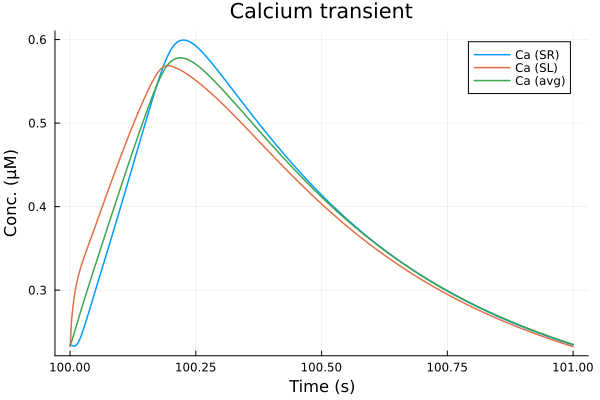

In [5]:
plot(sol, idxs=(sys.t / 1000, [sys.Cai_sub_SR, sys.Cai_sub_SL, sys.Cai_mean]), tspan=(100second, 101second), title="Calcium transient", xlabel="Time (s)", ylabel="Conc. (μM)", label=["Ca (SR)" "Ca (SL)" "Ca (avg)"])

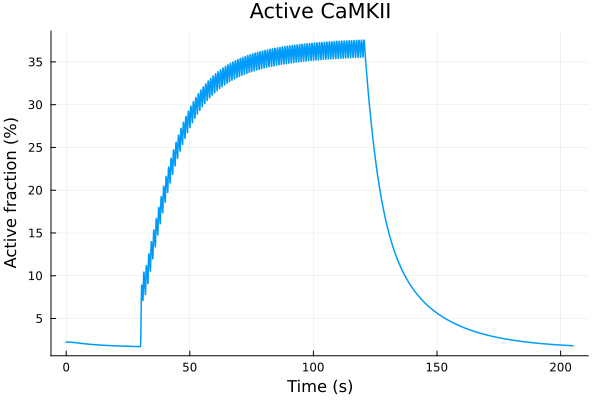

In [6]:
plot(sol, idxs=(sys.t / 1000, sys.CaMKAct * 100), title="Active CaMKII", label=false, ylabel="Active fraction (%)", xlabel="Time (s)")

## 0.1uM isoproterenol

In [7]:
prob2 = remake(prob, p=[sys.ISO => 0.1μM])
sol2 = solve(prob2, alg; callback)

retcode: Success
Interpolation: 3rd order Hermite
t: 4138-element Vector{Float64}:
      0.0
      0.019332211071584192
      0.09097534627605569
      0.20734339686524408
      0.4561200538541287
      1.0549952720719427
      2.0687580593126613
      3.5324261824253345
      6.954473747659736
     12.881140201769806
      ⋮
 152270.482708526
 157174.07587050938
 162194.01343084572
 168138.29627423352
 174916.26987407374
 181898.84288967986
 189304.81131705493
 197588.12256360063
 205000.0
u: 4138-element Vector{Vector{Float64}}:
 [0.0026, 830.0, 830.0, 0.00702, 0.966, 0.22156, 0.09243, 0.00188, 0.00977, 0.26081  …  0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, -68.79268, 13838.37602, 150952.75035000002]
 [0.002598561776347308, 829.9994983969723, 830.0014907812235, 0.007020212947405008, 0.9660018275573545, 0.221563993694571, 0.0924276668078433, 0.0018798283012559313, 0.009769882789165586, 0.2608055790255411  …  0.12113000000000056, 0.12113000000008267, 0.1211300000036

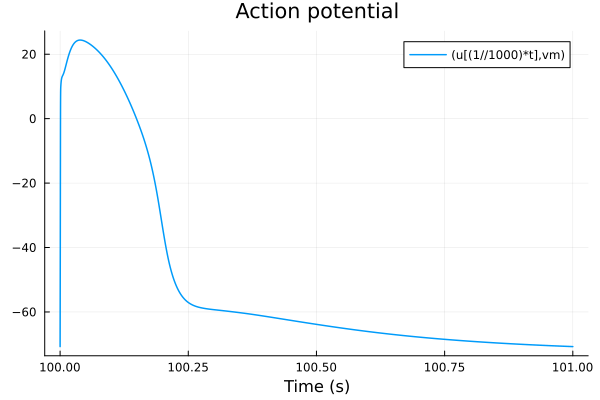

In [8]:
plot(sol2, idxs=(sys.t / 1000, sys.vm), tspan=(100second, 101second), title="Action potential", xlabel="Time (s)")

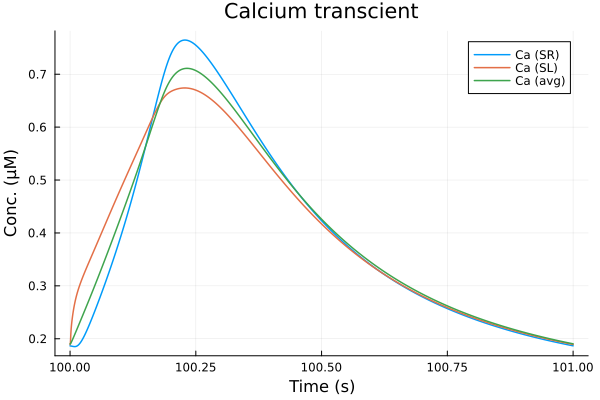

In [9]:
plot(sol2, idxs=(sys.t / 1000, [sys.Cai_sub_SR, sys.Cai_sub_SL, sys.Cai_mean]), tspan=(100second, 101second), title="Calcium transcient", xlabel="Time (s)", ylabel="Conc. (μM)", label=["Ca (SR)" "Ca (SL)" "Ca (avg)"])

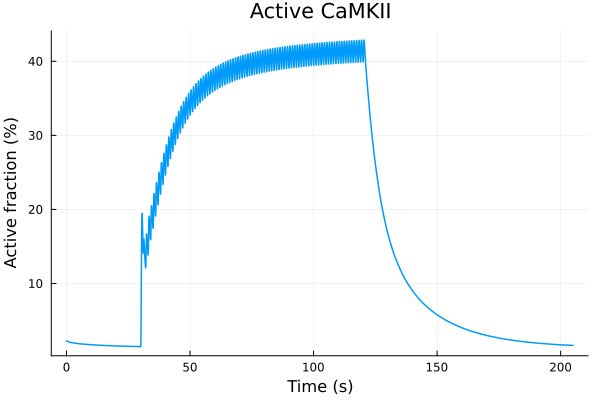

In [10]:
plot(sol2, idxs=(sys.t / 1000, sys.CaMKAct * 100), title="Active CaMKII", label=false, ylabel="Active fraction (%)", xlabel="Time (s)")

## Comparison

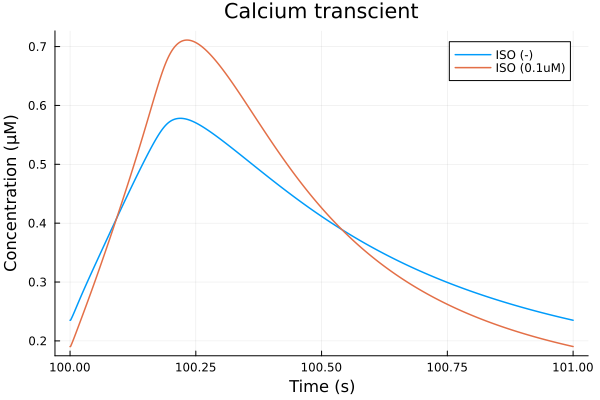

In [11]:
i = (sys.t / 1000, sys.Cai_mean)
tspan = (100second, 101second)
plot(sol, idxs=i, title="Calcium transcient", lab="ISO (-)"; tspan)
plot!(sol2, idxs=i, lab="ISO (0.1uM)", xlabel="Time (s)", ylabel="Concentration (μM)"; tspan)

In [12]:
savefig("iso-caT.pdf")

"/home/github/actions-runner-1/_work/camkii-cardiomyocyte-model/camkii-cardiomyocyte-model/.cache/docs/iso-caT.pdf"

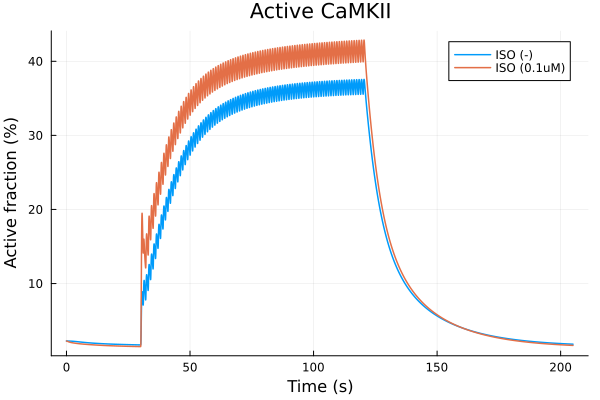

In [13]:
i = (sys.t / 1000, sys.CaMKAct * 100)
plot(sol, idxs=i, title="Active CaMKII", lab="ISO (-)")
plot!(sol2, idxs=i, lab="ISO (0.1uM)", ylabel="Active fraction (%)", xlabel="Time (s)")

In [14]:
savefig("iso-camkact.pdf")

"/home/github/actions-runner-1/_work/camkii-cardiomyocyte-model/camkii-cardiomyocyte-model/.cache/docs/iso-camkact.pdf"

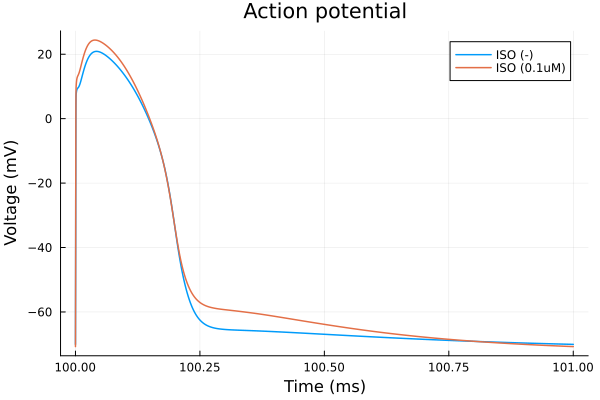

In [15]:
i = (sys.t / 1000, sys.vm)
tspan = (100second, 101second)
plot(sol, idxs=i, title="Action potential", lab="ISO (-)"; tspan)
plot!(sol2, idxs=i, lab="ISO (0.1uM)", xlabel="Time (ms)", ylabel="Voltage (mV)"; tspan)

## Experimental data

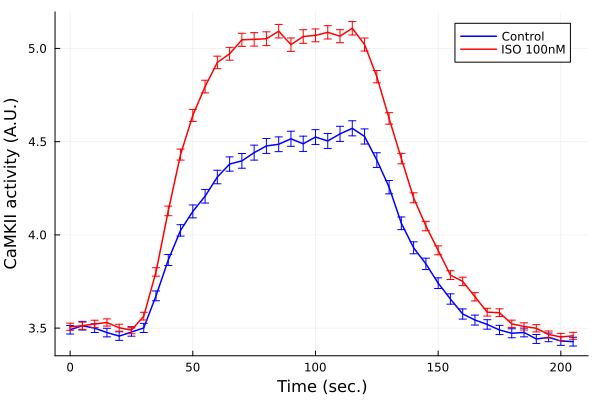

In [16]:
chemicaldf = CSV.read(joinpath(@__DIR__, "data/CaMKAR-chemical.csv"), DataFrame)
ts = Dates.value.(chemicaldf[!, "Time"]) ./ 10^9
ctl = chemicaldf[!, "Ctrl Mean"]
ctl_error = chemicaldf[!, "Ctrl SD"] ./ sqrt.(chemicaldf[!, "Ctrl N"])

iso = chemicaldf[!, "isoproterenol 100nM Mean"]
iso_error = chemicaldf[!, "isoproterenol 100nM SD"] ./ sqrt.(chemicaldf[!, "isoproterenol 100nM N"])

plot(ts, ctl, yerr=ctl_error, lab="Control", color=:blue, markerstrokecolor=:blue)
plot!(ts, iso, yerr=iso_error, lab="ISO 100nM", color=:red, markerstrokecolor=:red)
plot!(xlabel="Time (sec.)", ylabel="CaMKII activity (A.U.)")

In [17]:
savefig("iso-exp.pdf")

"/home/github/actions-runner-1/_work/camkii-cardiomyocyte-model/camkii-cardiomyocyte-model/.cache/docs/iso-exp.pdf"

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*